IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report
)

LOAD DATASET WITH INDICATORS

In [2]:
df = pd.read_csv(
    "../data/processed/reliance_with_indicators.csv",
    index_col=0,
    parse_dates=True
)

C:\Users\HP\AppData\Local\Temp\ipykernel_22052\1790526295.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


CHECK DATA

In [3]:
df.head()

,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,Signal_Line,Middle_Band,Upper_Band,Lower_Band
Price,,,,,,,,,,,,,,
Ticker,NaN,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01,675.324158,683.1528519736394,673.4900624593615,679.0819357370663,14004468,NaN,NaN,675.324158,NaN,0.000000,0.000000,NaN,NaN,NaN
2020-01-02,686.821228,689.3487905881979,676.397899264457,676.397899264457,17710316,NaN,NaN,676.419117,NaN,0.917145,0.183429,NaN,NaN,NaN
2020-01-03,687.648804,689.6618949086101,681.3187290426969,685.7922517653002,20984698,NaN,NaN,677.488611,NaN,1.691272,0.484998,NaN,NaN,NaN


SELECT FEATURES

In [21]:
features = [
    'Close',
    'Volume',
    'SMA_20',
    'SMA_50',
    'EMA_20',
    'RSI',
    'MACD'
]

CREATE NEXT DAY PRICE TARGET

In [39]:
df['Target_Price'] = df['Close'].shift(-1)

CREATE CLASSIFICATION TARGET

In [47]:
df = df.dropna()

In [48]:
X = df[features]

y_reg = df['Target_Price']

y_clf = df['Target_Class']

In [42]:
df['Target_Class'] = np.where(
    df['Target_Price'] > df['Close'],
    1,
    0
)

In [49]:
y_reg.isnull().sum()

np.int64(0)

In [50]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train_reg = y_reg[:split_index]
y_test_reg = y_reg[split_index:]

REMOVE NaN VALUES

In [43]:
df = df.dropna()

CREATE X AND y

X = INPUT FEATURES

In [22]:
X = df[features]

y = TARGET

In [23]:
y_clf = df['Target_Class']

In [24]:
y_reg = df['Target_Price']

TRAIN TEST SPLIT

In [56]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train_reg = y_reg[:split_index]
y_test_reg = y_reg[split_index:]

y_train_clf = y_clf[:split_index]
y_test_clf = y_clf[split_index:]

CHECK NaN

In [46]:
print(X.isnull().sum())
print(y_reg.isnull().sum())

Close     0
Volume    0
SMA_20    0
SMA_50    0
EMA_20    0
RSI       0
MACD      0
dtype: int64
1


LINEAR REGRESSION

In [57]:
lr = LinearRegression()

lr.fit(X_train, y_train_reg)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


PREDICTIONS

In [58]:
predictions = lr.predict(X_test)

In [59]:
print(len(y_test_reg))

print(len(predictions))

238
238


In [53]:
df = df.dropna()

In [54]:
y_reg.isnull().sum()

np.int64(0)

EVALUATE REGRESSION

In [60]:
mae = mean_absolute_error(y_test_reg, predictions)

rmse = np.sqrt(mean_squared_error(y_test_reg, predictions))

r2 = r2_score(y_test_reg, predictions)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 15.10823757244419
RMSE: 20.916713830404593
R2 Score: 0.9409083805816385


In [35]:
df.isnull().sum()

Close           0
High            0
Low             0
Open            0
Volume          0
SMA_20          0
SMA_50          0
EMA_20          0
RSI             0
MACD            0
Signal_Line     0
Middle_Band     0
Upper_Band      0
Lower_Band      0
Target_Price    0
Target_Class    0
dtype: int64

In [36]:
df = df.dropna()

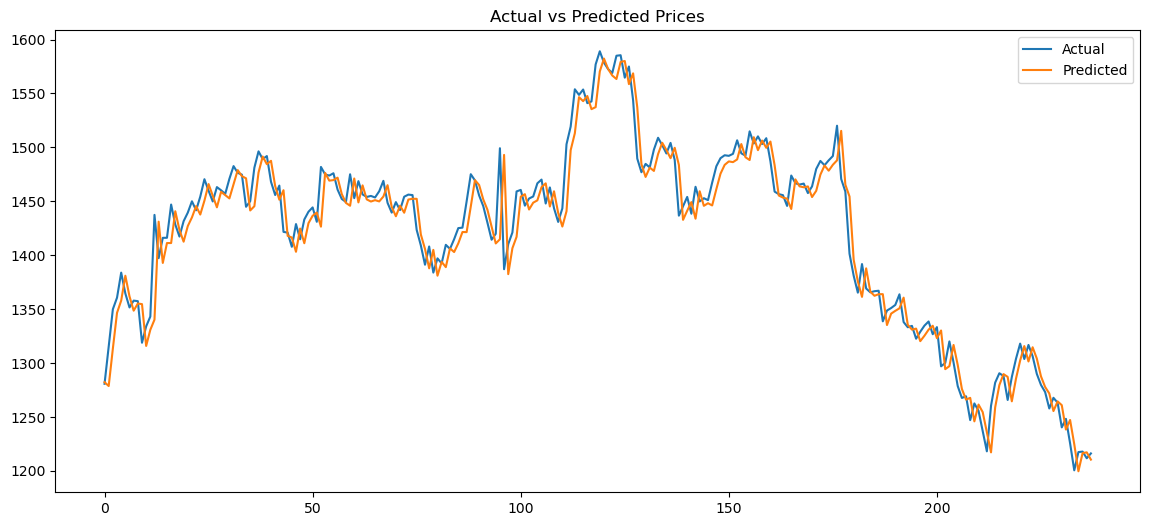

In [61]:
plt.figure(figsize=(14,6))

plt.plot(y_test_reg.values, label='Actual')

plt.plot(predictions, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Prices")

plt.show()

In [62]:
df.to_csv("../data/processed/final_ml_dataset.csv")